# Building a machine model to predict podcast listening Time

## Exploratory Data Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set()


In [2]:
data = pd.read_csv(r'playground-series-s5e4/train.csv')
data.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031


In [3]:
data.shape

(750000, 12)

In [4]:
data.describe(include = 'all')

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
count,750000.000000,750000,750000,662907.000000,750000,750000.000000,750000,750000,603970.000000,749999.000000,750000,750000.000000
unique,NaN,48,100,NaN,10,NaN,7,4,NaN,NaN,3,NaN
top,NaN,Tech Talks,Episode 71,NaN,Sports,NaN,Sunday,Night,NaN,NaN,Neutral,NaN
freq,NaN,22847,10515,NaN,87606,NaN,115946,196849,NaN,NaN,251291,NaN
mean,374999.500000,NaN,NaN,64.504738,NaN,59.859901,NaN,NaN,52.236449,1.348855,NaN,45.437406
std,216506.495284,NaN,NaN,32.969603,NaN,22.873098,NaN,NaN,28.451241,1.151130,NaN,27.138306
min,0.000000,NaN,NaN,0.000000,NaN,1.300000,NaN,NaN,0.000000,0.000000,NaN,0.000000
25%,187499.750000,NaN,NaN,35.730000,NaN,39.410000,NaN,NaN,28.380000,0.000000,NaN,23.178350
50%,374999.500000,NaN,NaN,63.840000,NaN,60.050000,NaN,NaN,53.580000,1.000000,NaN,43.379460
75%,562499.250000,NaN,NaN,94.070000,NaN,79.530000,NaN,NaN,76.600000,2.000000,NaN,64.811580


In [5]:
data.describe()

,id,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes
count,750000.000000,662907.000000,750000.000000,603970.000000,749999.000000,750000.000000
mean,374999.500000,64.504738,59.859901,52.236449,1.348855,45.437406
std,216506.495284,32.969603,22.873098,28.451241,1.151130,27.138306
min,0.000000,0.000000,1.300000,0.000000,0.000000,0.000000
25%,187499.750000,35.730000,39.410000,28.380000,0.000000,23.178350
50%,374999.500000,63.840000,60.050000,53.580000,1.000000,43.379460
75%,562499.250000,94.070000,79.530000,76.600000,2.000000,64.811580
max,749999.000000,325.240000,119.460000,119.910000,103.910000,119.970000


In [6]:
data.isnull().sum()

id                                  0
Podcast_Name                        0
Episode_Title                       0
Episode_Length_minutes          87093
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage    146030
Number_of_Ads                       1
Episode_Sentiment                   0
Listening_Time_minutes              0
dtype: int64

In [7]:
num_cols = [cols for cols in data.columns if data[cols].dtype != 'O']
num_cols

['id',
 'Episode_Length_minutes',
 'Host_Popularity_percentage',
 'Guest_Popularity_percentage',
 'Number_of_Ads',
 'Listening_Time_minutes']

In [8]:
"""
fig, axes = plt.subplots(2, 3,  figsize = (12, 10))
sns.histplot(data['Episode_Length_minutes'], kde = True, ax = axes[0,0])
axes[0,0].set_title('Episode_Length_minutes')

sns.histplot(data['Host_Popularity_percentage'], kde = True, ax = axes[0,1])
axes[0,1].set_title('Host_Popularity_percentage')

sns.histplot(data['Guest_Popularity_percentage'], kde = True, ax = axes[1,0])
axes[1,0].set_title('Guest_Popularity_percentage')

sns.histplot(data['Number_of_Ads'], kde = True, ax = axes[1,1])
axes[1,1].set_title('Number_of_Ads')

sns.histplot(data['Listening_Time_minutes'], kde = True, ax = axes[1,2])
axes[1,2].set_title('Listening_Time_minutes')

plt.tight_layout()
plt.show()
"""

"\nfig, axes = plt.subplots(2, 3,  figsize = (12, 10))\nsns.histplot(data['Episode_Length_minutes'], kde = True, ax = axes[0,0])\naxes[0,0].set_title('Episode_Length_minutes')\n\nsns.histplot(data['Host_Popularity_percentage'], kde = True, ax = axes[0,1])\naxes[0,1].set_title('Host_Popularity_percentage')\n\nsns.histplot(data['Guest_Popularity_percentage'], kde = True, ax = axes[1,0])\naxes[1,0].set_title('Guest_Popularity_percentage')\n\nsns.histplot(data['Number_of_Ads'], kde = True, ax = axes[1,1])\naxes[1,1].set_title('Number_of_Ads')\n\nsns.histplot(data['Listening_Time_minutes'], kde = True, ax = axes[1,2])\naxes[1,2].set_title('Listening_Time_minutes')\n\nplt.tight_layout()\nplt.show()\n"

In [9]:
"""
fig, axes = plt.subplots(2, 3,  figsize = (12, 10))
sns.histplot(np.log(data['Episode_Length_minutes']), kde = True, ax = axes[0,0])
axes[0,0].set_title('Episode_Length_minutes')

sns.histplot(np.log(data['Host_Popularity_percentage']), kde = True, ax = axes[0,1])
axes[0,1].set_title('Host_Popularity_percentage')

sns.histplot(np.log(data['Guest_Popularity_percentage']), kde = True, ax = axes[1,0])
axes[1,0].set_title('Guest_Popularity_percentage')

sns.histplot(np.log(data['Number_of_Ads']), kde = True, ax = axes[1,1])
axes[1,1].set_title('Number_of_Ads')

sns.histplot(np.log(data['Listening_Time_minutes']), kde = True, ax = axes[1,2])
axes[1,2].set_title('Listening_Time_minutes')

plt.tight_layout()
plt.show()
"""

"\nfig, axes = plt.subplots(2, 3,  figsize = (12, 10))\nsns.histplot(np.log(data['Episode_Length_minutes']), kde = True, ax = axes[0,0])\naxes[0,0].set_title('Episode_Length_minutes')\n\nsns.histplot(np.log(data['Host_Popularity_percentage']), kde = True, ax = axes[0,1])\naxes[0,1].set_title('Host_Popularity_percentage')\n\nsns.histplot(np.log(data['Guest_Popularity_percentage']), kde = True, ax = axes[1,0])\naxes[1,0].set_title('Guest_Popularity_percentage')\n\nsns.histplot(np.log(data['Number_of_Ads']), kde = True, ax = axes[1,1])\naxes[1,1].set_title('Number_of_Ads')\n\nsns.histplot(np.log(data['Listening_Time_minutes']), kde = True, ax = axes[1,2])\naxes[1,2].set_title('Listening_Time_minutes')\n\nplt.tight_layout()\nplt.show()\n"

In [10]:
df = data.copy()

In [11]:
"""
fig, axes = plt.subplots(2, 2,  figsize = (12, 10))
sns.scatterplot(data = data, x ='Episode_Length_minutes', y = 'Listening_Time_minutes', ax = axes[0,0])
axes[0,0].set_title('Episode_Length_minutes')

sns.scatterplot(data = data, x ='Host_Popularity_percentage', y = 'Listening_Time_minutes', ax = axes[0,1])
axes[0,1].set_title('Host_Popularity_percentage')

sns.scatterplot(data = data, x ='Guest_Popularity_percentage', y = 'Listening_Time_minutes', ax = axes[1,0])
axes[1,0].set_title('Guest_Popularity_percentage')

sns.scatterplot(data = data, x ='Number_of_Ads', y = 'Listening_Time_minutes', ax = axes[1,1])
axes[1,1].set_title('Number_of_Ads')

plt.tight_layout()
plt.show()
"""

"\nfig, axes = plt.subplots(2, 2,  figsize = (12, 10))\nsns.scatterplot(data = data, x ='Episode_Length_minutes', y = 'Listening_Time_minutes', ax = axes[0,0])\naxes[0,0].set_title('Episode_Length_minutes')\n\nsns.scatterplot(data = data, x ='Host_Popularity_percentage', y = 'Listening_Time_minutes', ax = axes[0,1])\naxes[0,1].set_title('Host_Popularity_percentage')\n\nsns.scatterplot(data = data, x ='Guest_Popularity_percentage', y = 'Listening_Time_minutes', ax = axes[1,0])\naxes[1,0].set_title('Guest_Popularity_percentage')\n\nsns.scatterplot(data = data, x ='Number_of_Ads', y = 'Listening_Time_minutes', ax = axes[1,1])\naxes[1,1].set_title('Number_of_Ads')\n\nplt.tight_layout()\nplt.show()\n"

In [12]:
df = df[df['Episode_Length_minutes'] < 150]

In [13]:
df = df[df['Host_Popularity_percentage'] < 110]

In [14]:
df = df[df['Host_Popularity_percentage'] > 20]

In [15]:
df = df[df['Guest_Popularity_percentage'] < 110]

In [16]:
df = df[df['Number_of_Ads'] < 20]

In [17]:
"""
fig, axes = plt.subplots(2, 3,  figsize = (12, 10))
sns.histplot(df['Episode_Length_minutes'], kde = True, ax = axes[0,0])
axes[0,0].set_title('Episode_Length_minutes')

sns.histplot(df['Host_Popularity_percentage'], kde = True, ax = axes[0,1])
axes[0,1].set_title('Host_Popularity_percentage')

sns.histplot(df['Guest_Popularity_percentage'], kde = True, ax = axes[1,0])
axes[1,0].set_title('Guest_Popularity_percentage')

sns.histplot(df['Number_of_Ads'], kde = True, ax = axes[1,1])
axes[1,1].set_title('Number_of_Ads')

sns.histplot(df['Listening_Time_minutes'], kde = True, ax = axes[1,2])
axes[1,2].set_title('Listening_Time_minutes')

plt.tight_layout()
plt.show()
"""

"\nfig, axes = plt.subplots(2, 3,  figsize = (12, 10))\nsns.histplot(df['Episode_Length_minutes'], kde = True, ax = axes[0,0])\naxes[0,0].set_title('Episode_Length_minutes')\n\nsns.histplot(df['Host_Popularity_percentage'], kde = True, ax = axes[0,1])\naxes[0,1].set_title('Host_Popularity_percentage')\n\nsns.histplot(df['Guest_Popularity_percentage'], kde = True, ax = axes[1,0])\naxes[1,0].set_title('Guest_Popularity_percentage')\n\nsns.histplot(df['Number_of_Ads'], kde = True, ax = axes[1,1])\naxes[1,1].set_title('Number_of_Ads')\n\nsns.histplot(df['Listening_Time_minutes'], kde = True, ax = axes[1,2])\naxes[1,2].set_title('Listening_Time_minutes')\n\nplt.tight_layout()\nplt.show()\n"

In [18]:
data

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031
...,...,...,...,...,...,...,...,...,...,...,...,...
749995,749995,Learning Lab,Episode 25,75.66,Education,69.36,Saturday,Morning,NaN,0.0,Negative,56.87058
749996,749996,Business Briefs,Episode 21,75.75,Business,35.21,Saturday,Night,NaN,2.0,Neutral,45.46242
749997,749997,Lifestyle Lounge,Episode 51,30.98,Lifestyle,78.58,Thursday,Morning,84.89,0.0,Negative,15.26000
749998,749998,Style Guide,Episode 47,108.98,Lifestyle,45.39,Thursday,Morning,93.27,0.0,Negative,100.72939


In [19]:
num_cols = [col for col in data.columns if data[col].dtypes != 'O']
cat_cols = [col for col in data.columns if data[col].dtypes == 'O']

In [20]:
num_cols = ['Episode_Length_minutes', 'Host_Popularity_percentage', 'Guest_Popularity_percentage', 'Number_of_Ads']
low_cat_cols = ['Genre', 'Publication_Day', 'Publication_Time', 'Episode_Sentiment']
high_cat_cols = ['Podcast_Name', 'Episode_Title']
target = ['Listening_Time_minutes']

## Model Building

In [21]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, cross_validate

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder


In [22]:
cat_onehot_encoding = OneHotEncoder(handle_unknown = 'ignore')
cat_ordinal_encoding = OrdinalEncoder(handle_unknown = 'use_encoded_value', unknown_value = np.nan)
num_pipeline_standardized = Pipeline([
    ('imputing', SimpleImputer(strategy = 'median')),
    ('standadizing', StandardScaler())
])

num_imputing = SimpleImputer(strategy = 'median')

In [23]:
column_transformer = ColumnTransformer(
    [
        ('cat_one_hot_encoding', cat_onehot_encoding, low_cat_cols),
        ('cat_ordinal_encoding', cat_ordinal_encoding, high_cat_cols),
        ('num_standization', num_pipeline_standardized, num_cols),
    ], 
    remainder = 'drop',
    verbose_feature_names_out = True,
    verbose = True,
    sparse_threshold = 0
)

In [24]:
X = column_transformer.fit_transform(data)

[ColumnTransformer]  (1 of 3) Processing cat_one_hot_encoding, total=   1.2s
[ColumnTransformer]  (2 of 3) Processing cat_ordinal_encoding, total=   0.6s
[ColumnTransformer]  (3 of 3) Processing num_standization, total=   0.6s


In [25]:
X.shape

(750000, 30)

In [26]:
input_data = data.drop('Listening_Time_minutes', axis = 1)

In [27]:
model = LinearRegression()
X_train, X_test, y_train, y_test = train_test_split(input_data, data[target], test_size = 0.2, random_state = 42)

In [28]:
model_pipeline = Pipeline(
    [
        ('preprocessing', column_transformer),
        ('modeling', model)
    ]
)

In [30]:
cv = KFold(n_splits = 5, shuffle = True, random_state= 42)

def rmse(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return np.sqrt(mse)

accuracy = make_scorer(rmse, greater_is_better=False)

cv_scores = cross_validate(
    estimator = model_pipeline,
    X = X_train,
    y = y_train,
    cv = cv,
    scoring = accuracy,
    return_train_score = True,
    return_estimator = True
)

[ColumnTransformer]  (1 of 3) Processing cat_one_hot_encoding, total=   0.8s
[ColumnTransformer]  (2 of 3) Processing cat_ordinal_encoding, total=   0.4s
[ColumnTransformer]  (3 of 3) Processing num_standization, total=   0.4s
[ColumnTransformer]  (1 of 3) Processing cat_one_hot_encoding, total=   0.8s
[ColumnTransformer]  (2 of 3) Processing cat_ordinal_encoding, total=   0.4s
[ColumnTransformer]  (3 of 3) Processing num_standization, total=   0.4s
[ColumnTransformer]  (1 of 3) Processing cat_one_hot_encoding, total=   0.8s
[ColumnTransformer]  (2 of 3) Processing cat_ordinal_encoding, total=   0.4s
[ColumnTransformer]  (3 of 3) Processing num_standization, total=   0.4s
[ColumnTransformer]  (1 of 3) Processing cat_one_hot_encoding, total=   0.8s
[ColumnTransformer]  (2 of 3) Processing cat_ordinal_encoding, total=   0.4s
[ColumnTransformer]  (3 of 3) Processing num_standization, total=   0.4s
[ColumnTransformer]  (1 of 3) Processing cat_one_hot_encoding, total=   0.8s
[ColumnTransfor

In [32]:
np.mean(cv_scores['test_score'])

np.float64(-13.376592071389314)

In [33]:
model_pipeline.fit(X_train, y_train)

[ColumnTransformer]  (1 of 3) Processing cat_one_hot_encoding, total=   0.9s
[ColumnTransformer]  (2 of 3) Processing cat_ordinal_encoding, total=   0.4s
[ColumnTransformer]  (3 of 3) Processing num_standization, total=   0.4s


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(sparse_threshold=0,
                                   transformers=[('cat_one_hot_encoding',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Genre', 'Publication_Day',
                                                   'Publication_Time',
                                                   'Episode_Sentiment']),
                                                 ('cat_ordinal_encoding',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=nan),
                                                  ['Podcast_Name',
                                                   'Episode_Title']),
                                                 ('num_standization',
                                                  Pipeline(steps=[('imputing',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standadizing',
                                                                   StandardScaler())]),
                                                  ['Episode_Length_minutes',
                                                   'Host_Popularity_percentage',
                                                   'Guest_Popularity_percentage',
                                                   'Number_of_Ads'])],
                                   verbose=True)),
                ('modeling', LinearRegression())])

In [34]:
y_pred = model_pipeline.predict(X_test)

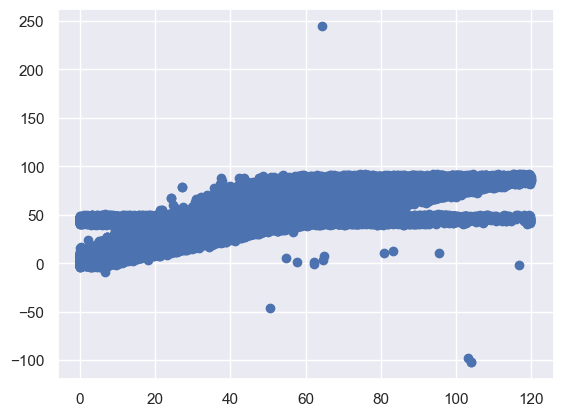

In [35]:
plt.scatter(y_test, y_pred)
plt.show()

In [37]:
train_rmse = rmse(y_test, y_pred)

In [38]:
train_rmse

np.float64(13.346343913022999)